In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df  = pd.read_excel("BlinkIT Grocery Data.xlsx")
df.head(6)

,Item Fat Content,Item Identifier,Item Type,Outlet Establishment Year,Outlet Identifier,Outlet Location Type,Outlet Size,Outlet Type,Item Visibility,Item Weight,Sales,Rating
0,Regular,FDX32,Fruits and Vegetables,2012,OUT049,Tier 1,Medium,Supermarket Type1,0.100014,15.10,145.4786,5.0
1,Low Fat,NCB42,Health and Hygiene,2022,OUT018,Tier 3,Medium,Supermarket Type2,0.008596,11.80,115.3492,5.0
2,Regular,FDR28,Frozen Foods,2016,OUT046,Tier 1,Small,Supermarket Type1,0.025896,13.85,165.0210,5.0
3,Regular,FDL50,Canned,2014,OUT013,Tier 3,High,Supermarket Type1,0.042278,12.15,126.5046,5.0
4,Low Fat,DRI25,Soft Drinks,2015,OUT045,Tier 2,Small,Supermarket Type1,0.033970,19.60,55.1614,5.0
5,low fat,FDS52,Frozen Foods,2020,OUT017,Tier 2,Small,Supermarket Type1,0.005505,8.89,102.4016,5.0


In [6]:
df.shape

(8523, 12)

In [7]:
df.columns

Index(['Item Fat Content', 'Item Identifier', 'Item Type',
       'Outlet Establishment Year', 'Outlet Identifier',
       'Outlet Location Type', 'Outlet Size', 'Outlet Type', 'Item Visibility',
       'Item Weight', 'Sales', 'Rating'],
      dtype='object')

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item Fat Content           8523 non-null   object 
 1   Item Identifier            8523 non-null   object 
 2   Item Type                  8523 non-null   object 
 3   Outlet Establishment Year  8523 non-null   int64  
 4   Outlet Identifier          8523 non-null   object 
 5   Outlet Location Type       8523 non-null   object 
 6   Outlet Size                8523 non-null   object 
 7   Outlet Type                8523 non-null   object 
 8   Item Visibility            8523 non-null   float64
 9   Item Weight                7060 non-null   float64
 10  Sales                      8523 non-null   float64
 11  Rating                     8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


In [11]:
df.describe()

,Outlet Establishment Year,Item Visibility,Item Weight,Sales,Rating
count,8523.000000,8523.000000,7060.000000,8523.000000,8523.000000
mean,2016.450546,0.066132,12.857645,140.992783,3.965857
std,3.189396,0.051598,4.643456,62.275067,0.605651
min,2011.000000,0.000000,4.555000,31.290000,1.000000
25%,2014.000000,0.026989,8.773750,93.826500,4.000000
50%,2016.000000,0.053931,12.600000,143.012800,4.000000
75%,2018.000000,0.094585,16.850000,185.643700,4.200000
max,2022.000000,0.328391,21.350000,266.888400,5.000000


In [12]:
df.isnull().sum()

Item Fat Content                0
Item Identifier                 0
Item Type                       0
Outlet Establishment Year       0
Outlet Identifier               0
Outlet Location Type            0
Outlet Size                     0
Outlet Type                     0
Item Visibility                 0
Item Weight                  1463
Sales                           0
Rating                          0
dtype: int64

In [15]:
df['Item Weight'] = df['Item Weight'].fillna(0)
df.isnull().sum()

Item Fat Content             0
Item Identifier              0
Item Type                    0
Outlet Establishment Year    0
Outlet Identifier            0
Outlet Location Type         0
Outlet Size                  0
Outlet Type                  0
Item Visibility              0
Item Weight                  0
Sales                        0
Rating                       0
dtype: int64

In [16]:
fat_content_fix = {
    'reg' : 'Regular',
    'low fat' : 'Low Fat',
    'LF' : 'Low Fat'
}

df['Item Fat Content'] = df['Item Fat Content'].replace(fat_content_fix)

In [18]:
df.head(5)

,Item Fat Content,Item Identifier,Item Type,Outlet Establishment Year,Outlet Identifier,Outlet Location Type,Outlet Size,Outlet Type,Item Visibility,Item Weight,Sales,Rating
0,Regular,FDX32,Fruits and Vegetables,2012,OUT049,Tier 1,Medium,Supermarket Type1,0.100014,15.10,145.4786,5.0
1,Low Fat,NCB42,Health and Hygiene,2022,OUT018,Tier 3,Medium,Supermarket Type2,0.008596,11.80,115.3492,5.0
2,Regular,FDR28,Frozen Foods,2016,OUT046,Tier 1,Small,Supermarket Type1,0.025896,13.85,165.0210,5.0
3,Regular,FDL50,Canned,2014,OUT013,Tier 3,High,Supermarket Type1,0.042278,12.15,126.5046,5.0
4,Low Fat,DRI25,Soft Drinks,2015,OUT045,Tier 2,Small,Supermarket Type1,0.033970,19.60,55.1614,5.0


In [19]:
df.fillna(df.mean(numeric_only=True), inplace=True)

In [20]:
df.drop_duplicates(inplace=True)

In [21]:
df.columns  = df.columns.str.strip().str.replace(" ", "_")

### EXPLORATORY DATA ANALYSIS (EDA)

In [24]:
# Total Sales
total_sales = df['Sales'].sum()
print("Total Sales - ", total_sales)


Total Sales -  1201681.4928


In [27]:
# sales by category
sales_by_category = df.groupby('Item_Type')['Sales'].sum().sort_values(ascending=True)
print(sales_by_category)

Item_Type
Seafood                    9077.8700
Breakfast                 15596.6966
Starchy Foods             21880.0274
Others                    22451.8916
Hard Drinks               29334.6806
Breads                    35379.1198
Soft Drinks               58514.1670
Meat                      59449.8638
Health and Hygiene        68025.8388
Baking Goods              81894.7364
Canned                    90706.7290
Dairy                    101276.4616
Frozen Foods             118558.8814
Household                135976.5254
Snack Foods              175433.9224
Fruits and Vegetables    178124.0810
Name: Sales, dtype: float64


In [28]:
# sales by outlet
sales_by_outlet = df.groupby('Outlet_Type')['Sales'].sum().sort_values(ascending=True)
print(sales_by_outlet)

Outlet_Type
Supermarket Type3    130714.6746
Supermarket Type2    131477.7764
Grocery Store        151939.1490
Supermarket Type1    787549.8928
Name: Sales, dtype: float64


In [32]:
# Average Rating
Average_Rating = df.groupby('Item_Type')['Rating'].mean()
print(Average_Rating)

Item_Type
Baking Goods             3.983025
Breads                   3.881275
Breakfast                3.932727
Canned                   3.994299
Dairy                    3.965836
Frozen Foods             3.971145
Fruits and Vegetables    3.956169
Hard Drinks              3.907477
Health and Hygiene       3.986154
Household                3.998681
Meat                     4.023059
Others                   3.954438
Seafood                  3.959375
Snack Foods              3.948917
Soft Drinks              3.920674
Starchy Foods            3.920270
Name: Rating, dtype: float64


### VISUALIZATION

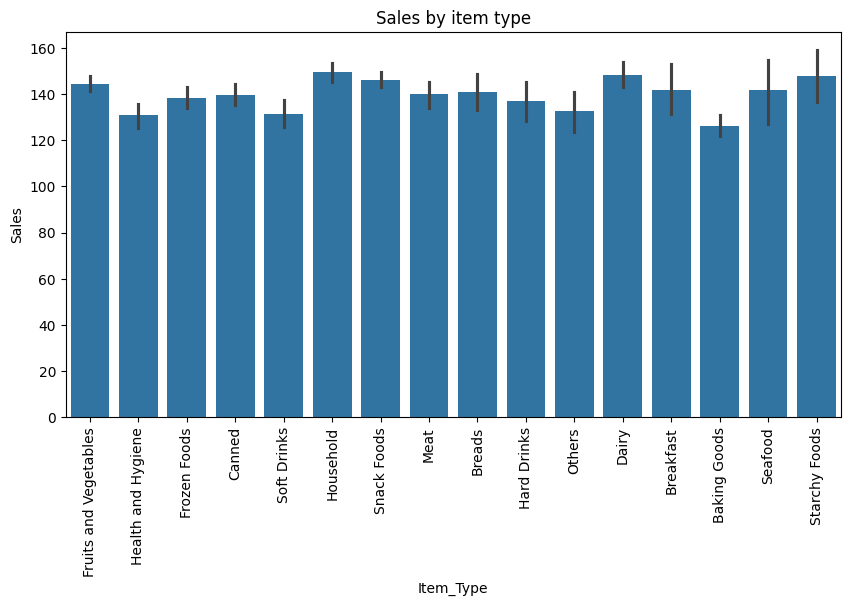

In [35]:
# Top Selling Categories
plt.figure(figsize=(10,5))
sns.barplot(x='Item_Type', y='Sales', data=df)
plt.xticks(rotation=90)
plt.title("Sales by item type")
plt.show()

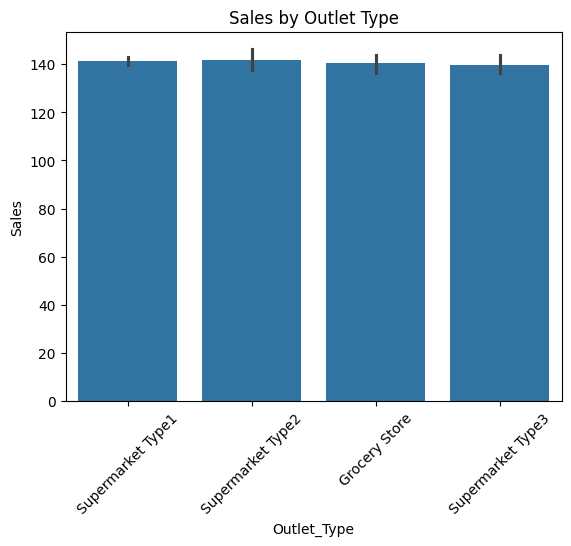

In [36]:
# Outlet Performance
sns.barplot(x='Outlet_Type', y='Sales', data=df)
plt.xticks(rotation=45)
plt.title("Sales by Outlet Type")
plt.show()

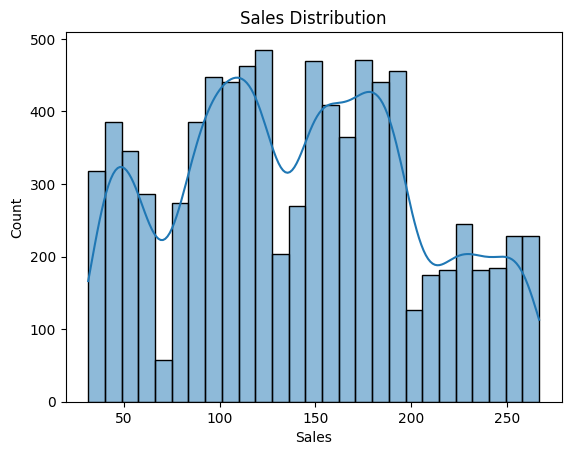

In [37]:
# Distribution Plot
sns.histplot(df['Sales'], kde=True)
plt.title("Sales Distribution")
plt.show()

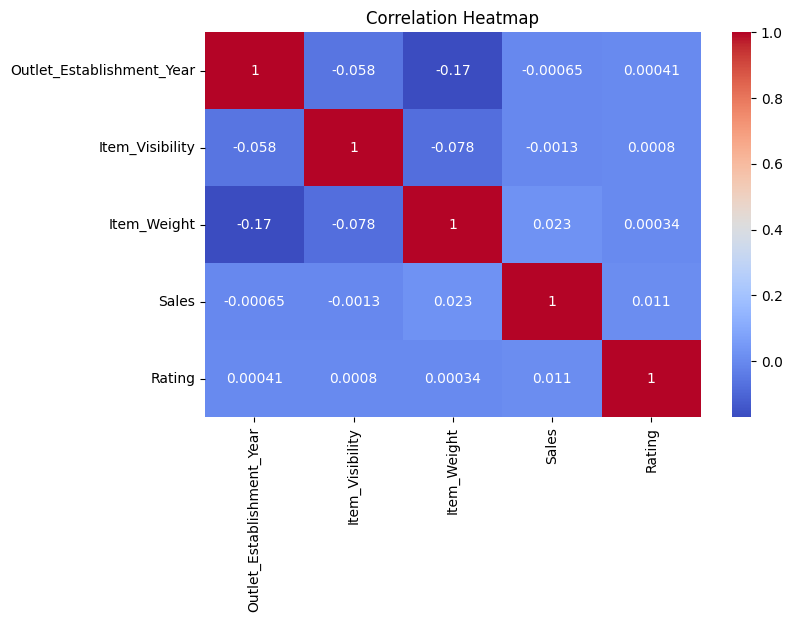

In [38]:
# Correlation Heatmap
plt.figure(figsize=(8,5))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()